In [768]:
# Autor:        Asier Ortiz García
# GitHub:       https://github.com/asier-ortiz/ai-course-notebooks/blob/main/entrega3_asier_ortiz.ipynb
# Kaggle:       https://www.kaggle.com/code/asierortiz/ai-based-rental-analysis-in-madrid-nlp-approaches
# nbviewer:     https://nbviewer.org/github/asier-ortiz/ai-course-notebooks/blob/main/entrega3_asier_ortiz.ipynb

# Proyecto de IA – Fase 3: Predicción de precios de viviendas mediante NLP

En esta fase del proyecto se aplican técnicas de **Procesamiento del Lenguaje Natural (NLP)** para predecir el precio de viviendas en Madrid a partir de su descripción textual.

Se desarrollan y comparan tres enfoques distintos:

1. **TF-IDF + modelos clásicos**
   Extracción de características mediante TF-IDF y uso de regresores tradicionales como: *Linear Regression, Ridge, Lasso, LinearSVR, SVR, Random Forest, AdaBoost, XGBoost, LGBM*

2. **Word Embeddings + CNN**
   Vectorización con embeddings preentrenados de **FastText** y entrenamiento de una **red neuronal convolucional** (CNN).

3. **Transformers**
   Fine-tuning de un modelo preentrenado en español (**RoBERTa**) adaptado a una tarea de regresión con `Trainer` de Hugging Face.

---

**Evaluación:**
En cada enfoque se aplican pasos de **preprocesamiento, entrenamiento y evaluación** con las siguientes métricas de regresión:
- `MAE`, `MAE (%)`, `MSE`, `RMSE`, `R2`

**Comparativa final:**
Se comparan los resultados obtenidos por cada modelo para determinar cuál ofrece un mejor rendimiento predictivo.

---

**Dataset**: [Idealista Madrid Listings](https://www.kaggle.com/datasets/fjcob1/idealista-madrid)
**Librerías clave**: `scikit-learn`, `nltk`, `gensim`, `transformers`, `pytorch`, `tensorflow`


## 1 - Importación de librerías y configuración inicial

In [769]:
# ------------------- Librerías estándar -------------------
import gzip
import importlib.util
import os
import re
import requests
import shutil
import string
import subprocess
import warnings
from collections import Counter

# ------------------- Visualización -------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ------------------- IPython -------------------
from IPython.display import clear_output

# ------------------- Carga de entorno y datos -------------------
from dotenv import load_dotenv
import kagglehub

# ------------------- Procesamiento de texto y NLP -------------------
import nltk
import spacy
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from unidecode import unidecode

# ------------------- Manejo de datos -------------------
import numpy as np
import pandas as pd

# ------------------- Scikit-learn -------------------
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR

# ------------------- Modelos adicionales -------------------
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# ------------------- Keras / TensorFlow -------------------
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ------------------- Transformers y PyTorch -------------------
import torch
from torch import nn
from datasets import Dataset
from tqdm.notebook import tqdm
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertConfig,
    BertModel,
    BertTokenizer,
    EarlyStoppingCallback,
    EvalPrediction,
    RobertaModel,
    RobertaPreTrainedModel,
    RobertaTokenizer,
    Trainer,
    TrainingArguments
)

# ------------------- Simple Transformers -------------------
from simpletransformers.classification import ClassificationModel, ClassificationArgs


In [770]:
# Establezco la coma como separador decimal en la salida de pandas
pd.options.display.float_format = lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Elimina el warning relacionado con "resume_download", que aparece porque esa función está deprecated
# Es un aviso por incompatibilidad entre versiones actuales de "transformers" y "huggingface_hub"
# No puedo usar versiones más nuevas por requisitos del entorno, así que lo ignoro manualmente
warnings.filterwarnings("ignore", message="`resume_download` is deprecated", category=FutureWarning)

## 2 - Funciones y variables auxiliares

In [771]:
# Constantes
RANDOM_STATE = 42
EPOCHS = 100
BATCH_SIZE = 32
VAL_BATCH_SIZE = 16
EARLY_STOPPING_PATIENCE = 3

# Diccionario para almacenar resultados de cada enfoque (TF-IDF, Word2Vec y Transformers)
all_approaches_results = {}

# Boolean para diferenciar entre entorno de desarrollo local o Kaggle
in_kaggle = False


# Funciones
def get_metrics(name, y_pred_log, y_true_log, transform_target=True):
    """
    Calcula métricas estándar de regresión a partir de las predicciones y valores reales en escala logarítmica

    Parámetros:
    - name (str): nombre del modelo
    - y_pred_log (array): predicciones del modelo en escala logarítmica
    - y_true_log (array): valores reales en escala logarítmica
    - transform_target (bool): si es True, aplica expm1 para revertir la escala logarítmica

    Devuelve:
    - Diccionario con métricas: MAE, MAE (%) respecto a la media, MSE, RMSE y R2
    """
    if transform_target:
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_true_log)
    else:
        y_pred = y_pred_log
        y_true = y_true_log

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae_pct = (mae / y_true.mean()) * 100

    return {
        "Model": name,
        "MAE": mae,
        "MAE (%)": mae_pct,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def plot_comparative_results(results_dict):
    """
    Genera gráficos comparativos de MAE y R2 para los distintos enfoques

    Parámetros:
    - results_dict (dict): Diccionario donde cada clave es el nombre del enfoque (ej. "TF-IDF, Word2Vec, Transformers")
      y cada valor es un DataFrame con métricas de modelos, que debe incluir las columnas "Model", "MAE" y "R2"
    """

    # Uno todos los DataFrames y añado la columna "Enfoque"
    combined_df = pd.concat([df.assign(Enfoque=name) for name, df in results_dict.items()], ignore_index=True)

    # Ordeno por MAE dentro de cada enfoque
    combined_df.sort_values(by=["Enfoque", "MAE"], inplace=True)

    # Paleta de colores por enfoque
    enfoque_palette = {
        name: color for name, color in zip(
            results_dict.keys(),
            sns.color_palette("Set2", n_colors=len(results_dict))
        )
    }

    # Subplot de MAE y R2 por modelo
    _, axes = plt.subplots(1, 2, figsize=(18, 6))

    # MAE
    sns.barplot(
        data=combined_df,
        y="Model",
        x="MAE",
        hue="Enfoque",
        dodge=True,
        ax=axes[0],
        palette=enfoque_palette
    )
    axes[0].set_title("Comparación de modelos por MAE")
    axes[0].set_xlabel("MAE (€)")
    axes[0].set_ylabel("Modelo")
    axes[0].invert_yaxis()
    axes[0].legend(title="Enfoque")

    # R2
    sns.barplot(
        data=combined_df,
        y="Model",
        x="R2",
        hue="Enfoque",
        dodge=True,
        ax=axes[1],
        palette=enfoque_palette
    )
    axes[1].set_title("Comparación de modelos por R2")
    axes[1].set_xlabel("R2")
    axes[1].set_ylabel("Modelo")
    axes[1].invert_yaxis()
    axes[1].legend(title="Enfoque")

    plt.tight_layout()
    plt.show()


## 3 - Carga de datos, análisis exploratorio y limpieza del dataset

### 3.1 - Carga o descarga del dataset

In [772]:
# Detecto si se está ejecutando en Kaggle
in_kaggle = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if in_kaggle:
    print("Ejecutando en Kaggle\n")

    # Ruta del dataset montado en "Input"
    dataset_dir = "/kaggle/input/idealista-nlp-dataset"

else:
    print("Ejecutando en entorno local\n")

    # Cargo la API key desde el fichero .env
    load_dotenv()
    os.environ["KAGGLE_API_KEY"] = os.getenv("KAGGLE_API_KEY")

    # Compruebo si ya tengo una copia local en ./data
    local_data_dir = os.path.join(os.getcwd(), "data")
    os.makedirs(local_data_dir, exist_ok=True)
    local_csv_path = os.path.join(local_data_dir, "Datos.csv")

    if os.path.exists(local_csv_path):
        print("CSV ya disponible localmente en: ./data/")
        # Redirige dataset_dir para usar la carpeta local
        dataset_dir = local_data_dir
    else:
        # Descarga el dataset con kagglehub si no está ya en caché
        dataset_dir = os.path.expanduser("~/.cache/kagglehub/datasets/fjcob1/idealista-madrid")

        if not os.path.exists(dataset_dir):
            print("Dataset no encontrado en caché. Descargando desde Kaggle...")
            dataset_dir = kagglehub.dataset_download("fjcob1/idealista-madrid")
        else:
            print("Dataset encontrado en caché:", dataset_dir)

        # Busca el CSV y lo copia a ./data
        for root, dirs, files in os.walk(dataset_dir):
            for file in files:
                if file == "Datos.csv":
                    csv_path_temp = os.path.join(root, file)
                    pd.read_csv(csv_path_temp).to_csv(local_csv_path, index=False)
                    print(f"CSV copiado a: {local_csv_path}")
                    break
            else:
                continue
            break

# Obtengo la ruta al CSV final según el entorno
if in_kaggle:
    # Busca en el dataset descargado en Kaggle
    csv_path = os.path.join(dataset_dir, "Datos.csv")
else:
    # En local está en ./data con nombre Datos.csv
    csv_path = os.path.join("data", "Datos.csv")

# Cargo el dataset
if os.path.exists(csv_path):
    print(f"\nCSV encontrado en: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    print("No se encontró el archivo CSV esperado")

Ejecutando en entorno local

CSV ya disponible localmente en: ./data/

CSV encontrado en: data/Datos.csv


### 3.2 - Análisis exploratorio

In [773]:
# Reviso cómo son las primeras filas del dataset
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,"2,00",S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,"3,00",N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,"1,00",S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,"1,00",S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,"3,00",S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [774]:
# Muestra aleatoria del 10% del DataFrame original para pruebas en local
df = df.sample(frac=0.1, random_state=RANDOM_STATE).copy()

In [775]:
# Me quedo solo con las columnas necesarias para el análisis
df = df[["PrecioActual", "descripcion"]]
print(df.columns)

Index(['PrecioActual', 'descripcion'], dtype='object')


In [776]:
# Compruebo cuántas filas y columnas tiene el dataset tras la selección de columnas
print("Número de filas y columnas en el dataset:")
print(df.shape)

Número de filas y columnas en el dataset:
(1183, 2)


In [777]:
# Muestro el número de valores nulos por columna
print(df.isnull().sum())

PrecioActual    0
descripcion     2
dtype: int64


In [778]:
# Elimino filas con descripción nula, ya que sólo hay unos pocos casos y así evíto errores posteriores en el preprocesado
df = df.dropna(subset=["descripcion"]).copy()
print(f"Número de filas tras eliminar nulos: {len(df)}")

Número de filas tras eliminar nulos: 1181


In [779]:
# Muestro ejemplos de textos en la columna "descripcion"
df["descripcion"].sample(5, random_state=RANDOM_STATE)

4028     Oportunidad única en TetuánVivienda con potenc...
3520     Situada en una de las zonas más cotizadas de H...
1261     CO PROPERTY os presenta este amplio piso de ca...
914      Descubre este impresionante piso ubicado en la...
10597    LA CASA AGENCY OFRECE EN EXCLUSIVA EL ÁTICO DÚ...
Name: descripcion, dtype: object

In [780]:
# Muestro la longitud de los textos
df["descripcion"].str.len().describe()

count   1.181,00
mean      316,74
std        46,10
min        20,00
25%       315,00
50%       317,00
75%       319,00
max       614,00
Name: descripcion, dtype: float64

In [781]:
# Muestro el número de palabras por descripción
df["descripcion"].str.split().str.len().describe()

count   1.181,00
mean       49,75
std         8,32
min         2,00
25%        47,00
50%        50,00
75%        53,00
max        92,00
Name: descripcion, dtype: float64

In [782]:
# Muestro las palabras más frecuentes
all_words = " ".join(df["descripcion"].dropna().tolist()).split()
word_freq = Counter(all_words)
display(word_freq.most_common(20))

[('de', 4299),
 ('en', 2561),
 ('y', 1920),
 ('con', 1620),
 ('la', 1267),
 ('una', 1079),
 ('un', 833),
 ('el', 823),
 ('a', 816),
 ('piso', 545),
 ('vivienda', 502),
 ('para', 492),
 ('del', 460),
 ('que', 416),
 ('se', 379),
 ('las', 352),
 ('este', 313),
 ('planta', 303),
 ('cocina', 253),
 ('zona', 249)]

In [783]:
# Muestro las estadísticas descriptivas de la columna "PrecioActual"
print(df["PrecioActual"].describe())

count        1.181,00
mean     1.018.140,72
std      1.217.824,87
min         62.200,00
25%        285.000,00
50%        570.000,00
75%      1.300.000,00
max     13.000.000,00
Name: PrecioActual, dtype: float64


In [784]:
# Reviso si hay valores nulos, ceros o negativos en la columna "PrecioActual"
print("Valores nulos:", df["PrecioActual"].isna().sum())
print("Valores igual a 0:", (df["PrecioActual"] == 0).sum())
print("Valores menores que 0:", (df["PrecioActual"] < 0).sum())

Valores nulos: 0
Valores igual a 0: 0
Valores menores que 0: 0


In [785]:
# Detecto outliers en la columna "PrecioActual" utilizando IQR
Q1 = df["PrecioActual"].quantile(0.25)
Q3 = df["PrecioActual"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["PrecioActual"] < lower_bound) | (df["PrecioActual"] > upper_bound)]
print(f"Número de outliers: {len(outliers)}")

Número de outliers: 86


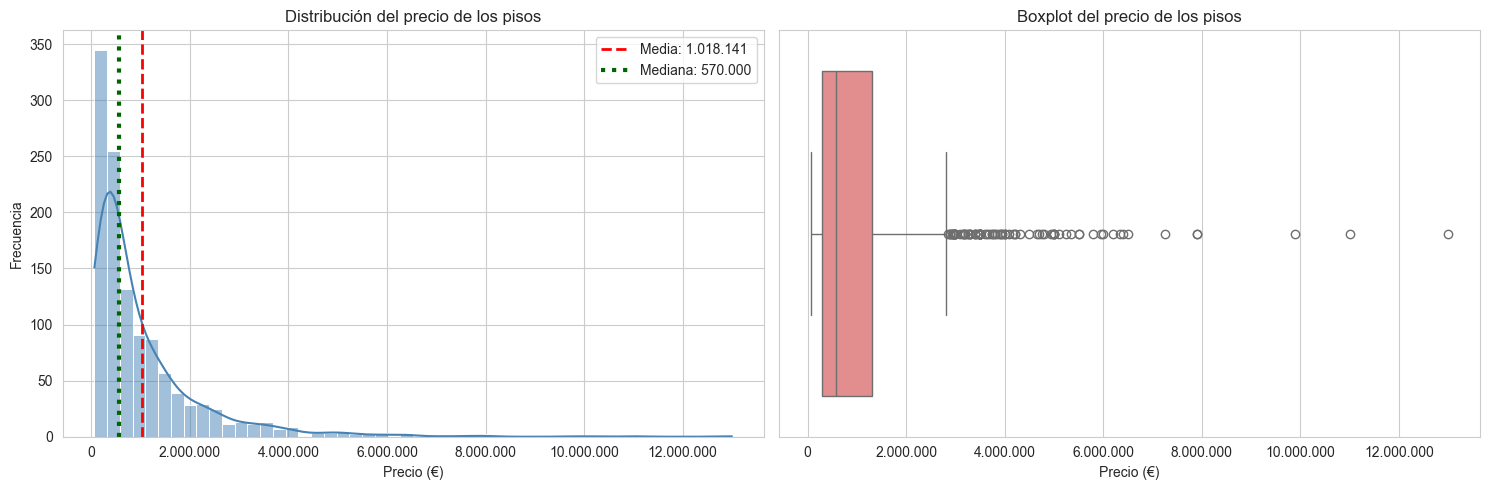

In [786]:
# Visualizo la distribución y los outliers del precio
_, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df["PrecioActual"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(df["PrecioActual"].mean(), color='red', linestyle='dashed', linewidth=2,
                label=f'Media: {df["PrecioActual"].mean():,.0f}'.replace(",", "."))
axes[0].axvline(df["PrecioActual"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
                label=f'Mediana: {df["PrecioActual"].median():,.0f}'.replace(",", "."))
axes[0].set_title("Distribución del precio de los pisos")
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
axes[0].legend()

# Boxplot
sns.boxplot(x=df["PrecioActual"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot del precio de los pisos")
axes[1].set_xlabel("Precio (€)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))

# Muestro las gráficas
plt.tight_layout()
plt.show()

### 3.3 - Tratamiento de outliers y transformación del precio

#### 3.3.1 - Eliminación de valores extremos

In [787]:
# Utilizo IQR para eliminar outliers del precio, ya que la distribución es muy asimétrica
# y presenta muchos valores extremos en el rango alto. Este enfoque mejora el rendimiento del modelo
# al reducir el impacto de datos atípicos que distorsionan el entrenamiento

# Eliminar outliers utilizando IQR
filtered_df = df[(df["PrecioActual"] >= Q1 - 1.5 * IQR) & (df["PrecioActual"] <= Q3 + 1.5 * IQR)].copy()

# Opción alternativa (no utilizada): filtrado manual por rango fijo:

# No escojo el filtrado manual porque impone límites arbitrarios que podrían eliminar
# datos válidos o introducir sesgos. En cambio, IQR es más flexible,
# basado en la propia distribución de los datos, y generaliza mejor si se cambia de dataset

# filtered_df = df[(df["PrecioActual"] >= 100_000) & (df["PrecioActual"] <= 350_000)].copy()

# Muestro cuántos datos se eliminaron tras aplicar el filtro
print(f"Número de registros antes: {len(df)}")
print(f"Número de registros después: {len(filtered_df)}")
print(f"Datos eliminados: {len(df) - len(filtered_df)}")

Número de registros antes: 1181
Número de registros después: 1095
Datos eliminados: 86


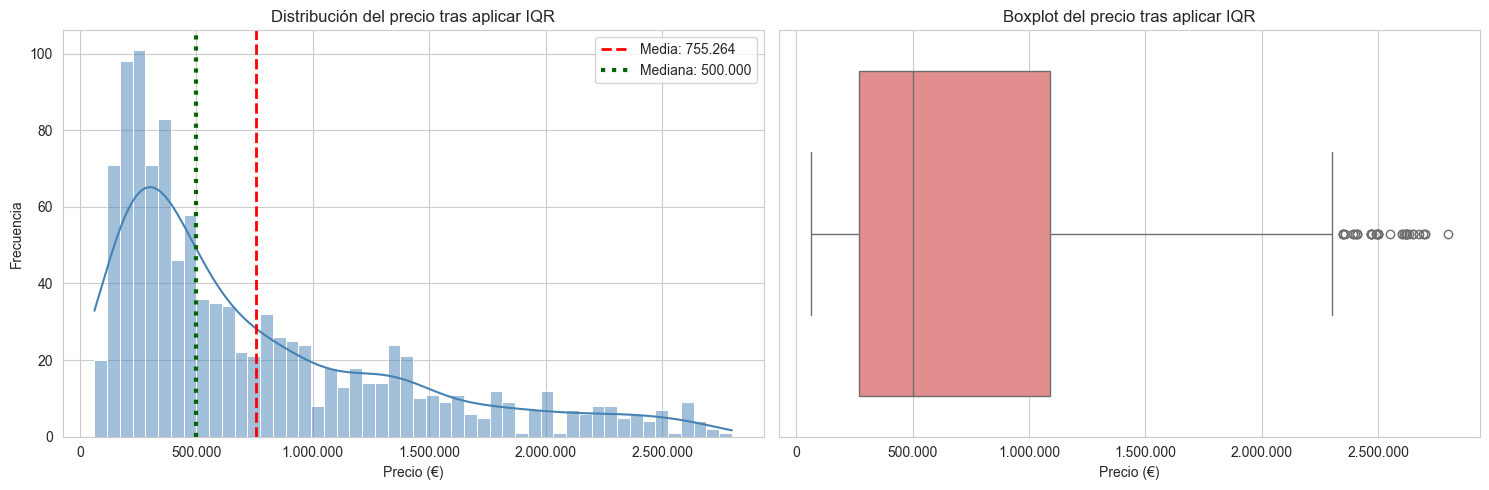

In [788]:
# Visualizo la distribución y los outliers tras aplicar el filtro IQR
_, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(filtered_df["PrecioActual"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(filtered_df["PrecioActual"].mean(), color='red', linestyle='dashed', linewidth=2,
                label=f'Media: {filtered_df["PrecioActual"].mean():,.0f}'.replace(",", "."))
axes[0].axvline(filtered_df["PrecioActual"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
                label=f'Mediana: {filtered_df["PrecioActual"].median():,.0f}'.replace(",", "."))
axes[0].set_title("Distribución del precio tras aplicar IQR")
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
axes[0].legend()

# Boxplot
sns.boxplot(x=filtered_df["PrecioActual"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot del precio tras aplicar IQR")
axes[1].set_xlabel("Precio (€)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))

# Muestro las gráficas
plt.tight_layout()
plt.show()

In [789]:
# Muestro las estadísticas descriptivas tras aplicar IQR al precio
print(filtered_df["PrecioActual"].describe())

count       1.095,00
mean      755.264,10
std       634.087,58
min        62.200,00
25%       271.500,00
50%       500.000,00
75%     1.090.000,00
max     2.800.000,00
Name: PrecioActual, dtype: float64


#### 3.3.2 - Transformación logarítmica del target

In [790]:
# Aplico log(1 + x) al precio para reducir la asimetría y estabilizar la varianza
# Esta transformación suaviza el efecto de los valores extremos y mejora el ajuste de los modelos lineales,
# que suelen funcionar mejor con distribuciones más normales
filtered_df["PrecioLog"] = np.log1p(filtered_df["PrecioActual"])

In [791]:
# Verifico que no haya valores atípicos o problemas en la nueva columna
print("Resumen estadístico de PrecioLog:")
print(filtered_df["PrecioLog"].describe())

Resumen estadístico de PrecioLog:
count   1.095,00
mean       13,19
std         0,84
min        11,04
25%        12,51
50%        13,12
75%        13,90
max        14,85
Name: PrecioLog, dtype: float64


In [792]:
# Comparo directamente precio original y su versión logarítmica
print("\nComparativa: Precio original vs PrecioLog (primeras filas):")
display(filtered_df[["PrecioActual", "PrecioLog"]].head())


Comparativa: Precio original vs PrecioLog (primeras filas):


,PrecioActual,PrecioLog
8169,1634000,"14,31"
900,348000,"12,76"
8075,140000,"11,85"
7625,199900,"12,21"
2816,520000,"13,16"


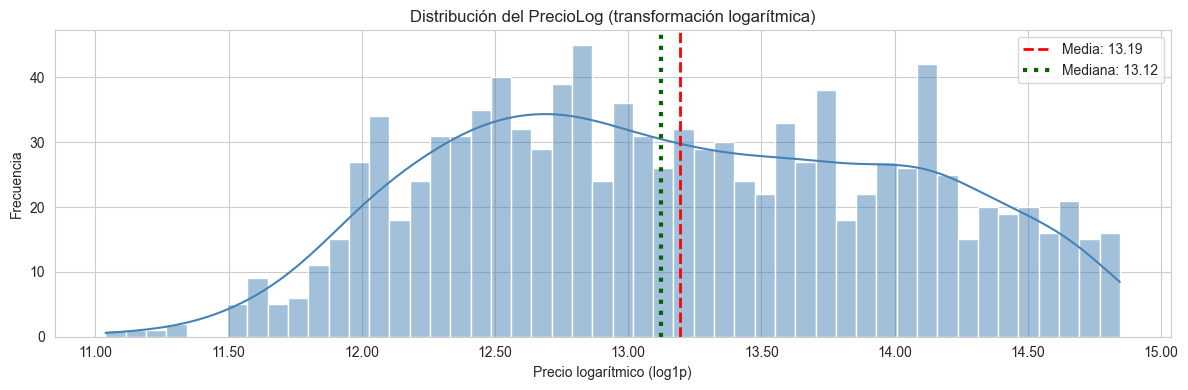

In [793]:
# Visualizo la nueva distribución del target transformado
plt.figure(figsize=(12, 4))
sns.histplot(filtered_df["PrecioLog"], bins=50, kde=True, color="steelblue")

# Añado la media y la mediana
plt.axvline(filtered_df["PrecioLog"].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Media: {filtered_df["PrecioLog"].mean():.2f}')
plt.axvline(filtered_df["PrecioLog"].median(), color='darkgreen', linestyle="dotted", linewidth=3,
            label=f'Mediana: {filtered_df["PrecioLog"].median():.2f}')

plt.title("Distribución del PrecioLog (transformación logarítmica)")
plt.xlabel("Precio logarítmico (log1p)")
plt.ylabel("Frecuencia")
plt.legend()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.2f}".replace(",", ".")))
plt.tight_layout()
plt.show()


## 4 - TF-IDF + modelos clásicos

### 4.1 - Preparación del texto con spaCy

In [794]:
# Verifico si el modelo ya está disponible antes de descargarlo
try:
    spacy.load("es_core_news_sm")
    print("El modelo 'es_core_news_sm' ya está instalado")
except OSError:
    print("Descargando el modelo 'es_core_news_sm'...")
    subprocess.run(["python", "-m", "spacy", "download", "es_core_news_sm"])
    clear_output(wait=True)
    print("Modelo descargado correctamente")

El modelo 'es_core_news_sm' ya está instalado


In [795]:
# Para este enfoque elimino URLs, números y signos de puntuación
# porque pueden meter ruido y no aportan valor semántico directo en TF-IDF
# En modelos como Word2Vec sí puede tener sentido usar máscaras del tipo <NUM> o <URL>,
# pero aquí prefiero una limpieza más agresiva para simplificar el vocabulario antes de vectorizar

# Cargo el modelo de spaCy y las stopwords en español
nlp = spacy.load("es_core_news_sm")
spanish_stopwords = set(stopwords.words("spanish"))


def clean_text_lemmatized(text):
    """
    Limpia el texto y devuelve sólo las palabras lematizadas relevantes.
    Se eliminan URLs, números, signos de puntuación y stopwords.
    """
    # Limpieza previa
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"http\S+", "", text)  # Elimina URLs
    text = re.sub(r"[^\w\s]", "", text)  # Elimina puntuación
    text = re.sub(r"\d+", "", text)  # Elimina números

    # Proceso con spaCy
    doc = nlp(text)

    # Lematizo y me quedo sólo con las palabras útiles
    lemmas = [
        token.lemma_ for token in doc
        if token.lemma_.isalpha()  # Me aseguro de que solamente sean letras y descarto números y símbolos
           and token.lemma_ not in spanish_stopwords  # Elimino stopwords comunes en español que no aportan significado
           and len(token.lemma_) > 2  # Evito palabras muy cortas que suelen ser poco informativas
    ]

    return " ".join(lemmas)


# Aplico la limpieza creando una nueva columna
filtered_df["clean_description"] = filtered_df["descripcion"].astype(str).apply(clean_text_lemmatized)

### 4.2 - Análisis exploratorio de textos lematizados

In [796]:
# Comparo el texto original versus el texto limpio
print("Ejemplos antes y después de aplicar limpieza y lematización:")
sample = filtered_df[["descripcion", "clean_description"]].sample(5, random_state=RANDOM_STATE)
display(sample)

Ejemplos antes y después de aplicar limpieza y lematización:


,descripcion,clean_description
457,>>> Bajo con Terraza de más de 120 metros (Inc...,bajo terraza mas metro incluir tendedero promo...
101,Agencia inmobiliaria de madrid zona san bernar...,agencia inmobiliario madrid zona san bernardo ...
1277,PRECIO NO NEGOCIABLE-ABSTENERSE AGENCIAS E INT...,precio agencia intermediario exterior reformad...
7988,MASTERPISO vende piso duplex en calle Valle In...,masterpiso vender piso duplex calle valle incl...
8807,OPORTUNIDAD en rentabilidad alquilado por 1400...,oportunidad rentabilidad alquilado EUR largo e...


In [797]:
# Muestro las estadísticas de los textos limpios
print("\nEstadísticas de las descripciones lematizadas:")
print(filtered_df["clean_description"].str.len().describe())


Estadísticas de las descripciones lematizadas:
count   1.095,00
mean      232,21
std        34,43
min         7,00
25%       224,00
50%       233,00
75%       243,00
max       470,00
Name: clean_description, dtype: float64


In [798]:
# Muestro el número de palabras por descripción después de aplicar la limpieza
print("\nNúmero de palabras por descripción tras la limpieza:")
print(filtered_df["clean_description"].str.split().str.len().describe())


Número de palabras por descripción tras la limpieza:
count   1.095,00
mean       28,11
std         4,36
min         1,00
25%        27,00
50%        28,00
75%        30,00
max        57,00
Name: clean_description, dtype: float64


### 4.3 - División de los datos

In [799]:
# Divido el dataset usando "PrecioLog" como target
X_train, X_test, y_train, y_test = train_test_split(filtered_df["clean_description"], filtered_df["PrecioLog"],
                                                    test_size=0.2, random_state=RANDOM_STATE)

### 4.4 - Definición de parámetros y modelos

In [800]:
# Parámetros compartidos para todos los modelos

# Configuración base de TF-IDF
shared_tfidf_params = {
    "tfidf__max_df": [0.75, 0.9, 1.0],  # Filtra palabras muy frecuentes y poco informativas
    "tfidf__min_df": [1, 3, 5],  # Filtra palabras poco frecuentes que pueden meter ruido
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],  # Uso unigramas, bigramas y trigramas para capturar más contexto
    "tfidf__sublinear_tf": [True],  # Aplico log(1 + tf) para reducir el impacto de palabras muy repetidas
    "tfidf__max_features": [5_000, 7_500, 10_000]  # Limito el tamaño del vocabulario para controlar la dimensionalidad
}

# Parámetros comunes para modelos de boosting
shared_boosting_params = {
    "model__n_estimators": [100, 200],  # Nº de árboles o iteraciones
    "model__learning_rate": [0.05, 0.1, 0.2]  # Tasa de aprendizaje ~> cuánto corrige cada nuevo árbol
}

# Profundidad de árboles para boosting
shared_tree_depth = {
    "model__max_depth": [3, 6, 10]  # Profundidad máxima de los árboles
}

In [801]:
# Diccionario de modelos y grids
models_and_params = {

    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__n_estimators": [50, 100, 200],  # Número de árboles
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0]  # Peso de cada nuevo modelo añadido
        }
    },

    "Lasso": {
        "model": Lasso(max_iter=10_000, random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__alpha": [0.01, 0.1, 1.0, 10.0]  # Regularización L1
        }
    },

    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            **shared_tfidf_params
        }
    },

    "LinearSVR": {
        "model": LinearSVR(max_iter=20_000, random_state=RANDOM_STATE),
        "params": {
            **shared_tfidf_params,
            "model__C": [0.01, 0.1, 1.0, 10.0],  # Regularización L2
            "model__epsilon": [0.0, 0.1, 0.2]  # Tolerancia a errores pequeños (margen)
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, verbose=0),
        "params": {
            **shared_tfidf_params,
            "model__n_estimators": [100, 200],  # Número de árboles
            "model__max_depth": [None, 10, 20]  # Profundidad máxima por árbol
        }
    },

    "Ridge": {
        "model": Ridge(),
        "params": {
            **shared_tfidf_params,
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]  # Regularización L2
        }
    },

    "SVR": {
        # Escalo los datos porque SVR es sensible a la escala de las variables
        # Uso with_mean=False porque TF-IDF genera una matriz dispersa y no se puede centrar
        "model": make_pipeline(StandardScaler(with_mean=False), SVR()),
        "params": {
            **shared_tfidf_params,
            "model__svr__C": [1, 10],  # Regularización C
            "model__svr__kernel": ["linear"]  # Kernel lineal para mayor eficiencia con TF-IDF
        }
    },

    "XGBoost": {
        "model": XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, verbosity=0),
        "params": {
            **shared_tfidf_params,
            **shared_boosting_params,
            **shared_tree_depth
        }
    },
}

### 4.5 - Entrenamiento de modelos

In [802]:
# Diccionario para almacenar los mejores modelos clásicos
best_classic_models = {}

# Entreno los todos los modelos definidos
for name, config in tqdm(models_and_params.items(), desc="Modelos clásicos", total=len(models_and_params)):
    print(f"\nEntrenando modelo: {name}")

    # Pipeline con TfidfVectorizer y el modelo correspondiente
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", config["model"])
    ])

    # Búsqueda de hiperparámetros con GridSearchCV y validación cruzada
    grid = GridSearchCV(
        pipeline,
        config["params"],
        cv=5,
        # Nota recordatoria sobre las métricas para regresión:
        # - MAE (Mean Absolute Error): error medio absoluto, fácil de interpretar y menos sensible a outliers
        # - MSE (Error cuadrático medio): da más peso a los errores grandes, útil si queremos penalizar mucho las predicciones muy desviadas
        # - R2 (Coeficiente de determinación): indica qué proporción de la variabilidad del precio se explica por el modelo
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )

    # Entreno el modelo
    grid.fit(X_train, y_train)

    # Muestro los mejores hiperparámetros encontrados
    print(f"Mejores parámetros para {name}:")
    for param, value in grid.best_params_.items():
        print(f"   • {param}: {value}")

    # Guardo el mejor modelo para su evaluación posterior
    best_classic_models[name] = grid.best_estimator_


Modelos clásicos:   0%|          | 0/8 [00:00<?, ?it/s]


Entrenando modelo: AdaBoost
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Mejores parámetros para AdaBoost:
   • model__learning_rate: 0.05
   • model__n_estimators: 50
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 1
   • tfidf__ngram_range: (1, 1)
   • tfidf__sublinear_tf: True

Entrenando modelo: Lasso
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores parámetros para Lasso:
   • model__alpha: 0.01
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 5
   • tfidf__ngram_range: (1, 1)
   • tfidf__sublinear_tf: True

Entrenando modelo: LinearRegression
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores parámetros para LinearRegression:
   • tfidf__max_df: 0.75
   • tfidf__max_features: 10000
   • tfidf__min_df: 1
   • tfidf__ngram_range: (1, 2)
   • tfidf__sublinear_tf: True

Entrenando modelo: LinearSVR
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Mejores 

/Users/asierortizgarcia/DocumentosMac/Git/module-2-notebooks/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros para XGBoost:
   • model__learning_rate: 0.2
   • model__max_depth: 6
   • model__n_estimators: 200
   • tfidf__max_df: 0.75
   • tfidf__max_features: 5000
   • tfidf__min_df: 3
   • tfidf__ngram_range: (1, 2)
   • tfidf__sublinear_tf: True


### 4.6 - Evaluación de los modelos y métricas finales

In [803]:
# Calcúlo las métricas para cada modelo clásico ya entrenado
metrics_list = []

for name, model in best_classic_models.items():
    # Predigo con el modelo y comparo en escala logarítmica
    y_pred_log = model.predict(X_test)
    y_true_log = y_test

    # Calcúlo las métricas
    metrics = get_metrics(name=name, y_pred_log=y_pred_log, y_true_log=y_true_log, transform_target=True)
    metrics_list.append(metrics)

# Creo un DataFrame con las métricas y lo ordeno por MSE
metrics_df = pd.DataFrame(metrics_list)
metrics_df_sorted = metrics_df.sort_values(by="MSE").reset_index(drop=True)
display(metrics_df_sorted)

# Guardo los resultados de este enfoque para la comparativa global
all_approaches_results["TF-IDF"] = metrics_df_sorted.copy()

,Model,MAE,MAE (%),MSE,RMSE,R2
0,Ridge,"309.067,57","41,08","228.115.019.299,85","477.613,88","0,43"
1,LinearRegression,"310.034,56","41,21","229.194.354.007,11","478.742,47","0,42"
2,LinearSVR,"316.141,41","42,02","234.784.248.017,63","484.545,40","0,41"
3,SVR,"316.762,60","42,10","242.532.068.297,26","492.475,45","0,39"
4,RandomForest,"336.208,54","44,69","270.243.033.239,55","519.849,05","0,32"
5,XGBoost,"340.654,41","45,28","274.398.946.337,44","523.831,03","0,31"
6,AdaBoost,"433.241,55","57,58","398.420.531.830,63","631.205,62","0,00"
7,Lasso,"468.742,40","62,30","436.549.183.430,89","660.718,69","-0,10"


## 5 - Word2Vec + CNN

### 5.1 - Carga o descarga del modelo FastText

In [804]:
# Nombre del archivo de embeddings preentrenados
filename = "cc.es.300.vec.gz"

# Detecto si se está ejecutando en Kaggle
in_kaggle = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

# En Kaggle: uso el archivo montado desde el dataset input
if in_kaggle:
    print("Usando FastText desde el input de Kaggle")

    # Ruta del dataset adjunto con el archivo FastText
    fasttext_dataset_path = "/kaggle/input/idealista-nlp-dataset"

    # Ruta al archivo dentro del input
    output_path = os.path.join(fasttext_dataset_path, filename)

# En local: descargo el archivo si no existe
else:
    print("Usando FastText en entorno local")

    # Ruta local donde se almacenará
    fasttext_dir = "embeddings/fasttext"
    os.makedirs(fasttext_dir, exist_ok=True)
    output_path = os.path.join(fasttext_dir, filename)

    # Si no está, lo descargo desde la web oficial
    if not os.path.exists(output_path):
        print("Descargando FastText en español...")
        url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
        response = requests.get(url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        with open(output_path, 'wb') as file, tqdm(
                desc=filename,
                total=total_size,
                unit='iB',
                unit_scale=True,
                unit_divisor=1024,
        ) as bar:
            for data in response.iter_content(block_size):
                file.write(data)
                bar.update(len(data))

        print("Descarga completada")
    else:
        print(f"FastText ya disponible en: {output_path}")

# Cargo el modelo desde la ruta definida
print("Cargando modelo FastText preentrenado en español...")
fasttext_model = KeyedVectors.load_word2vec_format(output_path, binary=False)
print("Modelo cargado correctamente.")

# Muestro la dimensión de los vectores
print("Dimensión del embedding:", fasttext_model.vector_size)

FastText ya disponible en: embeddings/fasttext/cc.es.300.vec.gz
Cargando modelo FastText preentrenado en español...
Modelo cargado correctamente.
Dimensión del embedding: 300


### 5.2 - Tokenización y análisis de longitud

In [805]:
# Tokenizo cada descripción usando NLTK para obtener una lista de palabras por texto
filtered_df["tokens"] = filtered_df["descripcion"].apply(word_tokenize)

# Preparo los textos y las etiquetas
tokenized_texts = filtered_df["tokens"].tolist()
labels_log = filtered_df["PrecioLog"].values

# Divido en train y test
X_train_tokens, X_test_tokens, y_train_log, y_test_log = train_test_split(tokenized_texts, labels_log, test_size=0.2,
                                                                          random_state=RANDOM_STATE)

# Analizo las longitudes de las secuencias para elegir una longitud máxima de padding adecuada para MAX_LEN
lengths = [len(tokens) for tokens in X_train_tokens]
print("Estadísticas de longitud de descripciones tokenizadas:")
print(f"Media: {np.mean(lengths):.2f}")
print(f"Mediana: {np.median(lengths):.2f}")
print(f"Percentiles [50, 75, 90, 95]: {np.percentile(lengths, [50, 75, 90, 95])}")

Estadísticas de longitud de descripciones tokenizadas:
Media: 55.47
Mediana: 56.00
Percentiles [50, 75, 90, 95]: [56.   59.   62.   63.25]


### 5.3 - Secuencias y padding con Keras

In [806]:
# Tokenizo con el Tokenizer de Keras
keras_tokenizer = Tokenizer()
keras_tokenizer.fit_on_texts(X_train_tokens + X_test_tokens)

# Convierto las listas de palabras a secuencias de índices
X_train_seq = keras_tokenizer.texts_to_sequences(X_train_tokens)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test_tokens)

# Aplico padding para que todas las secuencias tengan la misma longitud
MAX_LEN = 56
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

# Compruebo que el tamaño de las secuencias padded sea (nº de muestras, longitud máxima)
print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)

X_train_pad: (876, 56)
X_test_pad: (219, 56)


### 5.4 - Generación de la matriz de embeddings con FastText

In [807]:
# Dimensión de los vectores de embedding (FastText usa 300 dimensiones por defecto)
embedding_dim = 300

# Calculo el tamaño del vocabulario
vocab_size = len(keras_tokenizer.word_index) + 1  # +1 por el token de padding

# Inicializo una matriz de ceros donde se almacenarán los vectores de cada palabra
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Recorro cada palabra del vocabulario y su índice
for word, idx in keras_tokenizer.word_index.items():
    # Si la palabra está en el modelo FastText copio su vector en la matriz
    if word in fasttext_model:
        embedding_matrix[idx] = fasttext_model[word]


### 5.5 - Definición del modelo CNN

In [808]:
# Modelo secuencial
model = Sequential()

# Capa de entrada (secuencias de longitud fija)
model.add(Input(shape=(MAX_LEN,)))

# Capa de embedding con vectores FastText preentrenados
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True  # Afino los embeddings durante el entrenamiento
    )
)

# Uso capas convolucionales para capturar patrones locales del texto,
# seguidas de capas densas para aprender relaciones más profundas

# Capa convolucional 1: detecta combinaciones de 3 palabras
model.add(Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"))

# Capa convolucional 2: detecta combinaciones más largas de 5 palabras
model.add(Conv1D(filters=64, kernel_size=5, activation="relu", padding="same"))

# Reduce la salida a los valores más relevantes
model.add(GlobalMaxPooling1D())

# Capa totalmente conectada con ReLU
model.add(Dense(128, activation="relu"))

# Dropout para reducir overfitting
model.add(Dropout(0.4))

# Capa de salida escalar para regresión
model.add(Dense(1))

# Compilo el modelo con MSE como función de pérdida y MAE como métrica
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Muestro el resumen del modelo
model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_35 (Embedding)        │ (None, 56, 300)        │     1,761,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 56, 128)        │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 56, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_35         │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,401 (7.35 MB)

 Trainable params: 1,926,401 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

### 5.6 - Entrenamiento del modelo

In [809]:
# Callbacks
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)

# Entreno el modelo
history = model.fit(
    X_train_pad, y_train_log,
    validation_split=0.15,  # Menor split para que entrene con más datos
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 117.6616 - mae: 10.1078 - val_loss: 8.7394 - val_mae: 2.6008 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.8891 - mae: 2.4905 - val_loss: 2.1533 - val_mae: 1.1137 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.9517 - mae: 1.7717 - val_loss: 1.5399 - val_mae: 0.9527 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.8501 - mae: 1.5645 - val_loss: 1.2934 - val_mae: 0.8916 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.2975 - mae: 1.4407 - val_loss: 1.2367 - val_mae: 0.8675 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.6613 - mae: 1.5459 - val_loss: 0.9266 - val_mae: 0.7708 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.8415 - mae: 1.3428 - val_loss: 0.8163 - val_mae: 0.7182 - learning_rate: 0.0010
Epo

### 5.7 - Evaluación del modelo y métricas finales

In [810]:
# Predicciones en el conjunto de test
y_pred_log = model.predict(X_test_pad).flatten()

# Cálculo de métricas (con inversa del log1p)
word2vec_metrics = get_metrics(
    name="Word2Vec + CNN",
    y_pred_log=y_pred_log,
    y_true_log=y_test_log,
    transform_target=True
)

# Muestro las métricas en pantalla
print("\nMétricas del modelo Word2Vec + CNN:")
for k, v in word2vec_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

# Guardo para la comparativa global
all_approaches_results["Word2Vec + CNN"] = pd.DataFrame([word2vec_metrics])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Métricas del modelo Word2Vec + CNN:
Model: Word2Vec + CNN
MAE: 412577.6675
MAE (%): 54.8364
MSE: 390022498216.8088
RMSE: 624517.8126
R2: 0.0211


### 5.8 - Visualización del entrenamiento

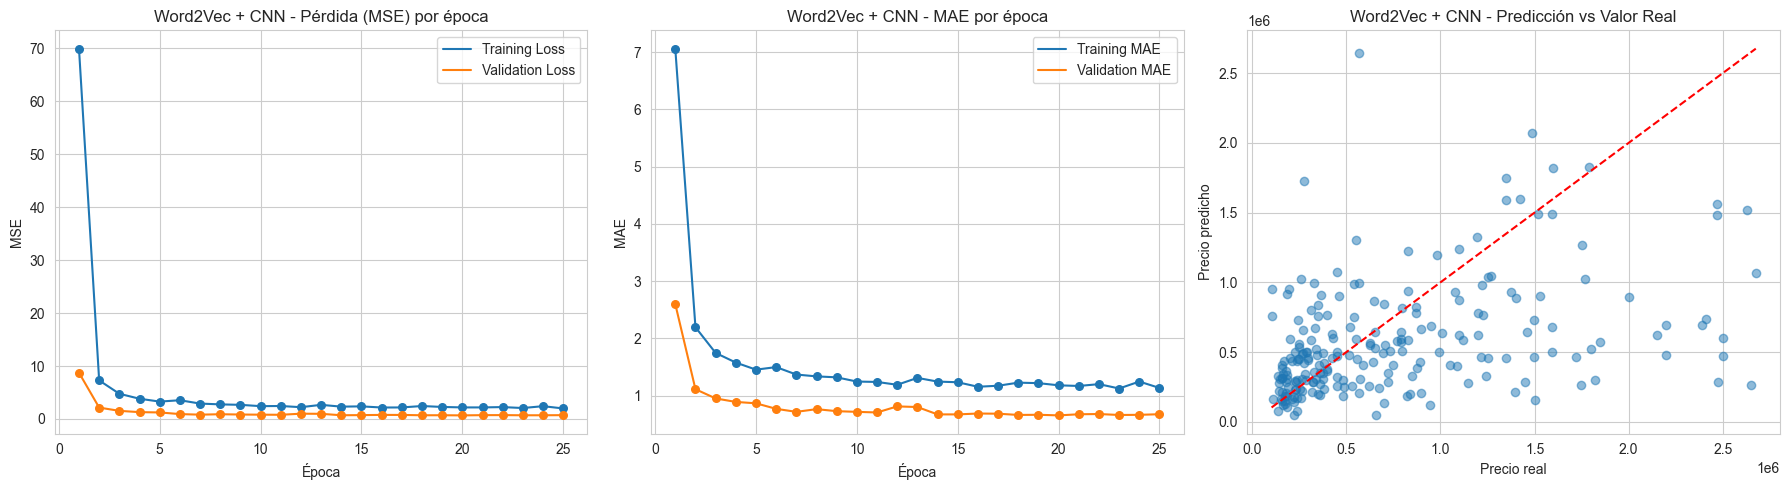

In [811]:
# Visualizo el entrenamiento sólo en este enfoque porque defino yo mismo la red y tengo acceso
# directo al historial de métricas con "history" desde Keras. Esto me permite analizar
# mejor el comportamiento del modelo en cada época

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(18, 5))

# MSE (Loss)
plt.subplot(1, 3, 1)
plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.scatter(epochs, history.history["loss"], s=30)
plt.scatter(epochs, history.history["val_loss"], s=30)
plt.title("Word2Vec + CNN - Pérdida (MSE) por época")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()

# MAE
plt.subplot(1, 3, 2)
plt.plot(epochs, history.history["mae"], label="Training MAE")
plt.plot(epochs, history.history["val_mae"], label="Validation MAE")
plt.scatter(epochs, history.history["mae"], s=30)
plt.scatter(epochs, history.history["val_mae"], s=30)
plt.title("Word2Vec + CNN - MAE por época")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()

# Dispersión: real vs predicho
plt.subplot(1, 3, 3)
plt.scatter(np.expm1(y_test_log), np.expm1(y_pred_log), alpha=0.5)
plt.plot([np.min(np.expm1(y_test_log)), np.max(np.expm1(y_test_log))],
         [np.min(np.expm1(y_test_log)), np.max(np.expm1(y_test_log))],
         'r--')
plt.title("Word2Vec + CNN - Predicción vs Valor Real")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")

plt.tight_layout()
plt.show()

## 6 - Transformers + RoBERTa

### 6.1 - Configuración de entorno

In [812]:
# Define el directorio base donde se guardarán modelos, tokenizers, etc.
os.environ["HF_HOME"] = "/tmp/huggingface"

# Evita warning del paralelismo
os.environ["TOKENIZERS_PARALLELISM"] = "false"

### 6.2 - Preparación de los datos para Transformers

In [813]:
# Me quedo solo con las columnas necesarias para el modelo de Transformers
transformers_df = filtered_df[["descripcion", "PrecioLog"]].copy()
transformers_df.rename(columns={"descripcion": "text", "PrecioLog": "label"}, inplace=True)

# Divido el dataset en train y test con la semilla global
train_df, test_df = train_test_split(transformers_df, test_size=0.2, random_state=RANDOM_STATE)

### 6.3 - Tokenización y conversión a Dataset

In [814]:
# Uso el modelo de RoBERTa preentrenado en español
roberta_es_model = "PlanTL-GOB-ES/roberta-base-bne"

# Utilizo el tokenizador oficial del modelo RoBERTa en español para convertir texto en tokens
tokenizer = RobertaTokenizer.from_pretrained(roberta_es_model)


def tokenize(example):
    """
    Tokeniza un ejemplo de texto usando el tokenizer de RoBERTa.

    Args:
        example (dict): Diccionario con la clave "text".

    Returns:
        dict: Diccionario con los tokens generados (input_ids y attention_mask),
              aplicando padding y truncado a longitud fija.
    """
    return tokenizer(example["text"], padding="max_length", truncation=True,
                     max_length=256)  # USo una longitud máxima de 256 tokens porque la mayoría de las descripciones tiene ~60 palabras


# Convierto los pandas.DataFrame a objetos Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Aplico la tokenización a ambos datasets
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Especifico que usaré tensores y las columnas a usar
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/876 [00:00<?, ? examples/s]

Map:   0%|          | 0/219 [00:00<?, ? examples/s]

### 6.4 - Definición de un modelo RoBERTa personalizado para regresión

In [815]:
# Defino una clase personalizada basada en Roberta para tareas de regresión
# Que hereda de RobertaPreTrainedModel e incluye métodos útiles
# como .from_pretrained(), manejo de pesos, guardado, etc...

# La arquitectura consiste en usar Roberta como extractor de características,
# y añadir una capa final lineal (densa) que devuelve un único valor escalar para regresión

class RobertaIdealistaRegressor(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)

        # Cargo el modelo base RoBERTa con el config recibido que incluye ya todos los hiperparámetros
        self.roberta = RobertaModel(config)

        # Capa de salida para regresión
        self.regressor = nn.Linear(config.hidden_size, 1)

        # Inicializo los pesos del modelo
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        # Envío los datos a RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        # Uso la salida del token de clasificación como representación del texto
        cls_output = outputs.last_hidden_state[:, 0]

        # Aplico la capa de regresión a ese vector
        prediction = self.regressor(cls_output).squeeze(-1)

        # Si tengo las etiquetas reales calculo el error cuadrático medio
        loss = None
        if labels is not None:
            loss_fn = nn.MSELoss()
            loss = loss_fn(prediction, labels)

        # Devuelvo la pérdida y la predicción y el Trainer se encarga del resto
        return {"loss": loss, "logits": prediction}


# Instancio el modelo y cargo los pesos preentrenados de RoBERTa
model = RobertaIdealistaRegressor.from_pretrained(roberta_es_model)

Some weights of RobertaIdealistaRegressor were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['regressor.bias', 'regressor.weight', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 6.5 - Configuración de los argumentos de entrenamiento

In [816]:
# Configuro los argumentos del entrenamiento
training_args = TrainingArguments(
    output_dir="/tmp/results_transformers", # Carpeta temporal donde se guardan los checkpoints, logs y el mejor modelo
    per_device_train_batch_size=BATCH_SIZE,  # Tamaño del batch para entrenamiento por dispositivo (en este caso, CPU)
    per_device_eval_batch_size=VAL_BATCH_SIZE,  # Tamaño del batch para validación/evaluación
    num_train_epochs=EPOCHS,  # Número máximo de épocas (el early stopping detendrá antes si no mejora)
    learning_rate=2e-5,  # Tasa de aprendizaje del optimizador AdamW
    weight_decay=0.01,  # Decaimiento de pesos (regularización L2)
    lr_scheduler_type="reduce_lr_on_plateau", # Reducción de la tasa de aprendizaje si la métrica de evaluación no mejora
    evaluation_strategy="epoch",  # Evalúa el modelo al final de cada época para ver si mejora
    logging_strategy="epoch",  # Guarda los logs de entrenamiento al final de cada época
    save_strategy="epoch",  # Guarda un checkpoint al final de cada época sólo si ha mejorado
    load_best_model_at_end=True,  # Al final del entrenamiento, carga automáticamente el mejor modelo
    metric_for_best_model="loss",  # Métrica usada para decidir cuál es el mejor modelo
    greater_is_better=False,  # Como la pérdida es mejor cuanto más baja, esto debe ser False
    report_to="none",  # Evita que mande logs a herramientas externas como WandB
    disable_tqdm=False,  # Activa la barra de progreso
    seed=RANDOM_STATE  # Semilla para reproducibilidad del entrenamiento
)

### 6.6 - Entrenamiento del modelo

In [817]:
# Función personalizada para ver las métricas durante el entrenamiento
def compute_metrics(pred: EvalPrediction):
    """
    Calcula métricas de regresión (MAE, MSE, RMSE y R2) a partir de las predicciones del modelo.
    Aplica la inversa del log1p (expm1) para llevar los valores a la escala original del precio.

    Args:
        pred (EvalPrediction): Objeto con predicciones y etiquetas verdaderas.

    Returns:
        dict: Diccionario con las métricas calculadas.
    """
    y_pred = np.expm1(pred.predictions)
    y_true = np.expm1(pred.label_ids)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


# Instancio y configuro el Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Entreno el modelo
trainer.train()

Epoch,Training Loss,Validation Loss,Mae,Mse,Rmse,R2
1,93.112200,41.283543,751458.250000,963132915712.000000,981393.354222,-1.417224
2,31.396800,26.382563,749008.312500,959459819520.000000,979520.198628,-1.408005
3,25.000300,23.649334,747933.500000,957850124288.000000,978698.178341,-1.403965
4,22.627800,21.477156,746771.750000,956113551360.000000,977810.590738,-1.399607
5,20.508400,19.459879,745343.125000,953981927424.000000,976719.984143,-1.394257
6,18.518400,17.561567,743567.937500,951337680896.000000,975365.408909,-1.387621
7,16.731000,15.735312,741302.875000,947975225344.000000,973640.192958,-1.379182
8,14.932700,14.016298,738460.625000,943769255936.000000,971477.872077,-1.368626
9,13.289400,12.388364,734854.875000,938456842240.000000,968739.821748,-1.355293
10,11.827600,10.837682,730215.062500,931657482240.000000,965224.058051,-1.338229


TrainOutput(global_step=1232, training_loss=7.363950166282812, metrics={'train_runtime': 1280.4011, 'train_samples_per_second': 68.416, 'train_steps_per_second': 2.187, 'total_flos': 5070630731341824.0, 'train_loss': 7.363950166282812, 'epoch': 44.0})

### 6.7 - Evaluación del modelo y métricas finales

In [818]:
# Obtengo las predicciones logarítmicas
predictions = trainer.predict(test_dataset)
y_pred_log = predictions.predictions
y_true_log = predictions.label_ids

# Aplico la función get_metrics para calcular las métricas y revertir el log1p
transformers_metrics = get_metrics(
    name="RoBERTa",
    y_pred_log=y_pred_log,
    y_true_log=y_true_log,
    transform_target=True
)

# Muestro métricas finales del modelo
print("\nMétricas del modelo Transformers:")
for k, v in transformers_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

# Guardo en la variable global para la comparativa final
all_approaches_results["Transformers"] = pd.DataFrame([transformers_metrics])


Métricas del modelo Transformers:
Model: RoBERTa
MAE: 269704.4688
MAE (%): 35.8469
MSE: 169555181568.0000
RMSE: 411770.7877
R2: 0.5745


### 6.8 - Limpieza del entorno

In [819]:
# Elimino los directorios temporales utilizados por Hugging Face para:
# - los checkpoints y resultados del entrenamiento
# - la caché del modelo y del tokenizador RoBERTa
shutil.rmtree("/tmp/results_transformers", ignore_errors=True)
shutil.rmtree("/tmp/huggingface", ignore_errors=True)

## 7 - Comparación de resultados y análisis personal

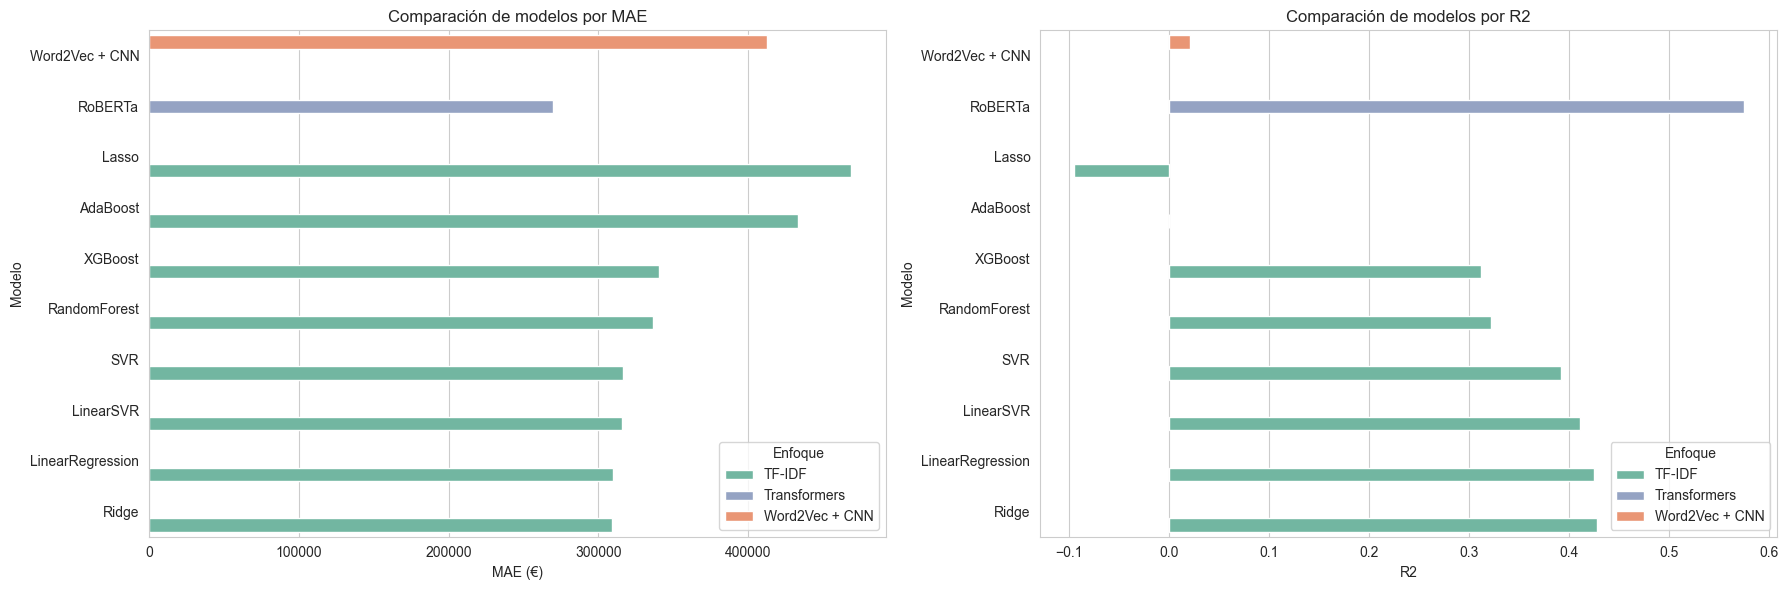

In [820]:
# Muestro los resultados de todos los modelos de los distintos enfoques
plot_comparative_results(all_approaches_results)

In [ ]:
# RoBERTa ha sido el modelo que mejor ha funcionado en general, tanto en MAE como especialmente en R2, donde supera claramente al resto.
# Tiene sentido porque es un modelo preentrenado muy potente, capaz de entender mejor el lenguaje gracias al fine-tuning aplicado sobre descripciones reales.

# El enfoque con Word2Vec + CNN ha sido el que peor ha rendido con el 10% de datos.
# Ya probé a entrenarlo con el 100% del dataset y las métricas mejoraban mucho,
# pero he decidido dejarlo también con el 10% para que la comparativa entre modelos sea justa.
# Probablemente necesita más datos para generalizar bien.

# Los modelos clásicos con TF-IDF han obtenido resultados bastante decentes, sobre todo Ridge y Linear Regression.
# Son modelos más simples, pero con una buena representación como TF-IDF pueden seguir siendo competitivos.

# Durante las pruebas también realicé experimentos filtrando las viviendas dentro de un rango de precio más limitado (entre 100K € y 350K €),
# y efectivamente las métricas mejoraban. Aun así, no me pareció un enfoque del todo adecuado,
# ya que estaría condicionando artificialmente la distribución de precios.
# Por eso, opté por eliminar outliers utilizando el método IQR, que es una técnica más robusta y justa para este tipo de análisis.

## 8 - Referencias, guías y enlaces útiles

In [821]:
#################################################################################################################################################

# Modelos clásicos:

# AdaBoost
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html

# Lasso
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

# LGBM
# Ref. https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

# Linear Regression
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

# LinearSVR
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html

# Random Forest Regressor
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

# Ridge Regression
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

# Support Vector Regressor
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

# XGBoost Regressor
# Ref. https://xgboost.readthedocs.io/en/stable/python/python_api/xgboost.XGBRegressor.html

# GridSearch
# Ref. https://medium.com/%40Mandeep2002/gridsearchcv-key-concepts-8f98ceb633e4

#################################################################################################################################################

# Word2Vec

# Embeddings preentrenados de FastText en español
# https://fasttext.cc/docs/en/crawl-vectors.html

# Gensim
# https://radimrehurek.com/gensim/models/word2vec.html

#################################################################################################################################################

# Transformers:

# Trainer, TrainingArguments, evaluación, etc...
# https://huggingface.co/docs/transformers/main_classes/trainer

# Tokenizers
# https://huggingface.co/docs/transformers/main_classes/tokenizer

# Datasets
# https://huggingface.co/docs/datasets

# RobertaPreTrainedModel
# https://huggingface.co/docs/transformers/model_doc/roberta#transformers.RobertaPreTrainedModel

# Modelo RoBERTa
# https://huggingface.co/PlanTL-GOB-ES/roberta-base-bne

# Simple Transformers
# https://simpletransformers.ai/docs/regression/

#################################################################################################################################################

# Otros enlaces de interés:

# Ref. https://spacy.io/models/es
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
# Ref. https://simpletransformers.ai/
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
# Ref. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
# Ref. https://www.kaggle.com/code/pierremegret/gensim-word2vec-tutorial
# Ref. https://www.youtube.com/watch?v=Q2NtCcqmIww
# Ref. https://radimrehurek.com/gensim/apiref.html
# Ref. https://medium.com/@kalpit.sharma/mastering-random-forest-hyperparameter-tuning-for-enhanced-machine-learning-models-2d1a8c6c426f
# Ref. https://medium.com/@joachimiak.krzysztof/featurizing-text-for-regression-part-i-scikit-learn-5b45cb6b7029
# Ref. https://www.youtube.com/watch?v=ATK6fm3cYfI
# Ref. https://github.com/codebasics/nlp-tutorials/blob/main/12_tf_idf/tf_idf_tutorial_nlp_codebasics.ipynb
# Ref. https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673
# Ref. https://huggingface.co/PlanTL-GOB-ES/roberta-base-bne#how-to-use
# Ref. https://achimoraites.medium.com/fine-tuning-roberta-for-topic-classification-with-hugging-face-transformers-and-datasets-library-c6f8432d0820
# Ref. https://medium.com/ilb-labs-publications/fine-tuning-bert-for-a-regression-task-is-a-description-enough-to-predict-a-propertys-list-price-cf97cd7cb98a
